In [1]:
%%capture
%pip install accelerate peft bitsandbytes transformers trl

In [ ]:
#!huggingface-cli login
from huggingface_hub import login
login("token")

In [3]:
import os
import torch
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig
from trl import SFTTrainer

In [4]:
# Model from Hugging Face hub
base_model = "Joseph7D/llama-2-7b-emotion-detector-v9"

# New instruction dataset
emotion_dataset = "Joseph7D/prompt-emotion-dataset-v2"


In [22]:
dataset = load_dataset(emotion_dataset, split='test')

In [23]:
dataset

Dataset({
    features: ['text'],
    num_rows: 3366
})

In [10]:
compute_dtype = getattr(torch, "float16")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=False,
)
# Load base model
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    quantization_config=quant_config,
    device_map={"": 0}
)
model.config.use_cache = False
model.config.pretraining_tp = 1


# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/quantizers/auto.py:222: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/164 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

In [11]:
!kill 26235

/bin/bash: line 1: kill: (26235) - No such process


In [12]:
# Suprime mensajes de advertencia
logging.set_verbosity(logging.CRITICAL)

# Define el prompt con el formato adecuado
prompt = """Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Me indigna ver cómo algunas personas menosprecian los derechos humanos"
"""

# Genera el resultado usando el pipeline
pipe = pipeline(task="text-generation", model=model, tokenizer=tokenizer, max_length=200)
result = pipe(f"<s>[INST] {prompt} [/INST]")

# Muestra el resultado
print(result[0]['generated_text'])

<s>[INST] Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Me indigna ver cómo algunas personas menosprecian los derechos humanos"
 [/INST] ira 


In [13]:
# Suprime mensajes de advertencia
logging.set_verbosity(logging.CRITICAL)

# Define el prompt con el formato adecuado
prompt = """Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Me indigna ver cómo algunas personas menosprecian los derechos humanos"
"""

# Genera el resultado usando el pipeline
pipe = pipeline(task="text-generation", model=model, tokenizer=tokenizer, max_length=200)
result = pipe(f"<s>[INST] {prompt} [/INST]")

# Muestra el resultado
print(result[0]['generated_text'])

<s>[INST] Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Me indigna ver cómo algunas personas menosprecian los derechos humanos"
limitate a responder solo la única emoción
 [/INST] ira 


# Validation

In [15]:
print(dataset[0])

{'text': '<s>[INST] Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.\n\nTexto: "Y cuando juega mejor, gol cosas del fútbol" [/INST] neutral </s>'}


In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import re
from tqdm import tqdm


# Separar prompt (input) y etiqueta (label) del formato instruct
def parse_sample(sample):
    text = sample["text"]  # campo 'text' del dataset
    inst_match = re.search(r"\[INST\](.*?)\[/INST\]", text, re.DOTALL)
    label_match = re.search(r"\[/INST\](.*?)</s>", text, re.DOTALL)

    if inst_match and label_match:
        input_text = inst_match.group(1).strip()
        label = label_match.group(1).strip().lower()
        return {"input": input_text, "label": label}
    else:
        return None

parsed_data = [parse_sample(s) for s in dataset if parse_sample(s)]


In [25]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Preparar listas con datos de entrada, etiqueta real y predicha ---
texts = []        # el texto original de cada muestra
true_labels = []  # etiqueta real
pred_labels = []  # etiqueta generada

for sample in tqdm(parsed_data, desc="eval samples"):
    # parsed_data es la lista de dicts con 'input' y 'label'
    prompt = f"<s>[INST] {sample['input']} [/INST]"
    inputs = tokenizer(prompt, return_tensors="pt", return_attention_mask=True).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=10,
            do_sample=False
        )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    pred = decoded.split("[/INST]")[-1].strip().lower()
    # pred = decoded.split("Respuesta:")[-1].strip().lower()

    texts.append(sample["input"])
    true_labels.append(sample["label"])
    pred_labels.append(pred)

# --- 2. Construir un DataFrame con los resultados ---
df = pd.DataFrame({
    "text": texts,
    "true": true_labels,
    "pred": pred_labels
})
# Añadimos una columna booleana de acierto
df["correct"] = df["true"] == df["pred"]

# --- 3. Métricas globales ---
print(classification_report(df["true"], df["pred"], digits=4))
print("Confusion matrix:\n", confusion_matrix(df["true"], df["pred"]))

# --- 4. Separar correctos e incorrectos ---
df_correct   = df[df["correct"]]
df_incorrect = df[~df["correct"]]

# También puedes exportarlos:
df_incorrect.to_csv("errores_test.csv", index=False)
df_correct.to_csv("aciertos_test.csv", index=False)


eval samples: 100%|██████████| 3366/3366 [43:37<00:00,  1.29it/s]

              precision    recall  f1-score   support

     alegría     0.8891    0.8574    0.8730       561
    disgusto     0.9514    0.9412    0.9462       561
         ira     0.8679    0.8200    0.8433       561
       miedo     0.9475    0.9323    0.9398       561
     neutral     0.8318    0.9430    0.8839       561
    tristeza     0.8623    0.8485    0.8553       561

    accuracy                         0.8904      3366
   macro avg     0.8917    0.8904    0.8902      3366
weighted avg     0.8917    0.8904    0.8902      3366

Confusion matrix:
 [[481   1  14   3  40  22]
 [  1 528  15   0  17   0]
 [ 17  18 460   4  33  29]
 [  7   3  11 523   2  15]
 [ 12   3   7   0 529  10]
 [ 23   2  23  22  15 476]]


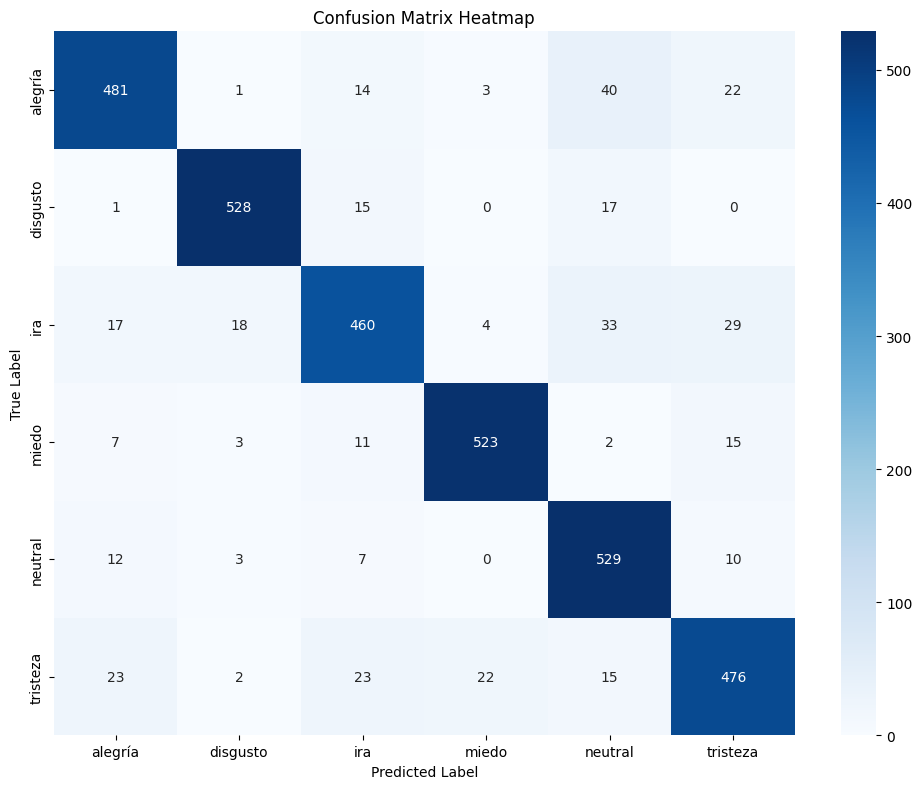

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Obtener etiquetas únicas (ordenadas por aparición en etiquetas reales)
labels = sorted(list(set(true_labels + pred_labels)))

# Matriz de confusión como array
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# Crear mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

# Etiquetas y título
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()
